In [17]:
import pandas as pd
from IPython.display import display
from rdkit import Chem
from rdkit.Chem import Draw

import deepmedchem as dmc

In [18]:
DATABASE = "enamine-real-v5a"

QUERIES = {
    "urea ring junction": ("smiles", "CNC(=O)N1CCC1"),
    "acyclic hydrazide": ("smarts", "[N;R0][N;R0]C(=O)"),
    "acyclic urea": ("smarts", "[N;R0]C(=O)[N;R0]"),
    "protic amide or acid": ("smarts", "[O,N;H1]C(=O)"),
}

In [19]:
results = {
    name: dmc.substructure(pattern, format=query_format, database=DATABASE, limit=16, timeout_seconds=60)
    for name, (query_format, pattern) in QUERIES.items()
}

for name, result in results.items():
    print(f"{name}: {len(result)} hits")

urea ring junction: 16 hits
acyclic hydrazide: 16 hits
acyclic urea: 16 hits
protic amide or acid: 16 hits


In [20]:
def query_mol(query_format, pattern):
    return Chem.MolFromSmarts(pattern) if query_format == "smarts" else Chem.MolFromSmiles(pattern)


def draw_highlighted(name, mols_per_row=4):
    query_format, pattern = QUERIES[name]
    pat = query_mol(query_format, pattern)
    result = results[name]

    molecules = []
    highlight_atoms = []
    legends = []

    for hit in result.hits:
        mol = Chem.MolFromSmiles(hit.smiles)
        if mol is None:
            continue
        match = mol.GetSubstructMatch(pat)
        molecules.append(mol)
        highlight_atoms.append(list(match))
        score = f"{hit.score:.4f}" if hit.score is not None else "exact"
        legends.append(f"Rank {hit.rank}  score={score}\n{hit.product_id}")

    return Draw.MolsToGridImage(
        molecules,
        molsPerRow=mols_per_row,
        subImgSize=(300, 250),
        legends=legends,
        highlightAtomLists=highlight_atoms,
        useSVG=True,
    )

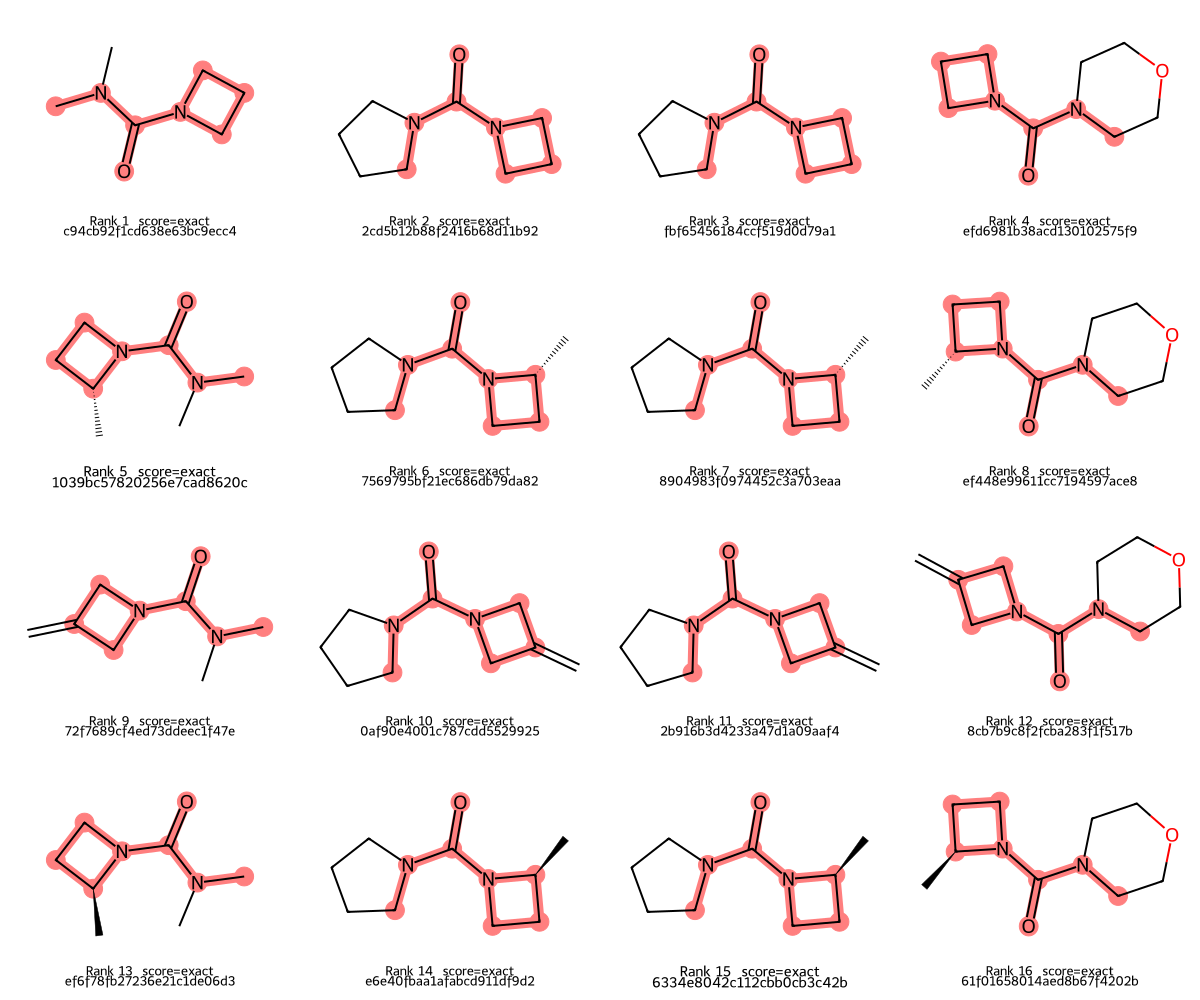

In [21]:
draw_highlighted("urea ring junction")

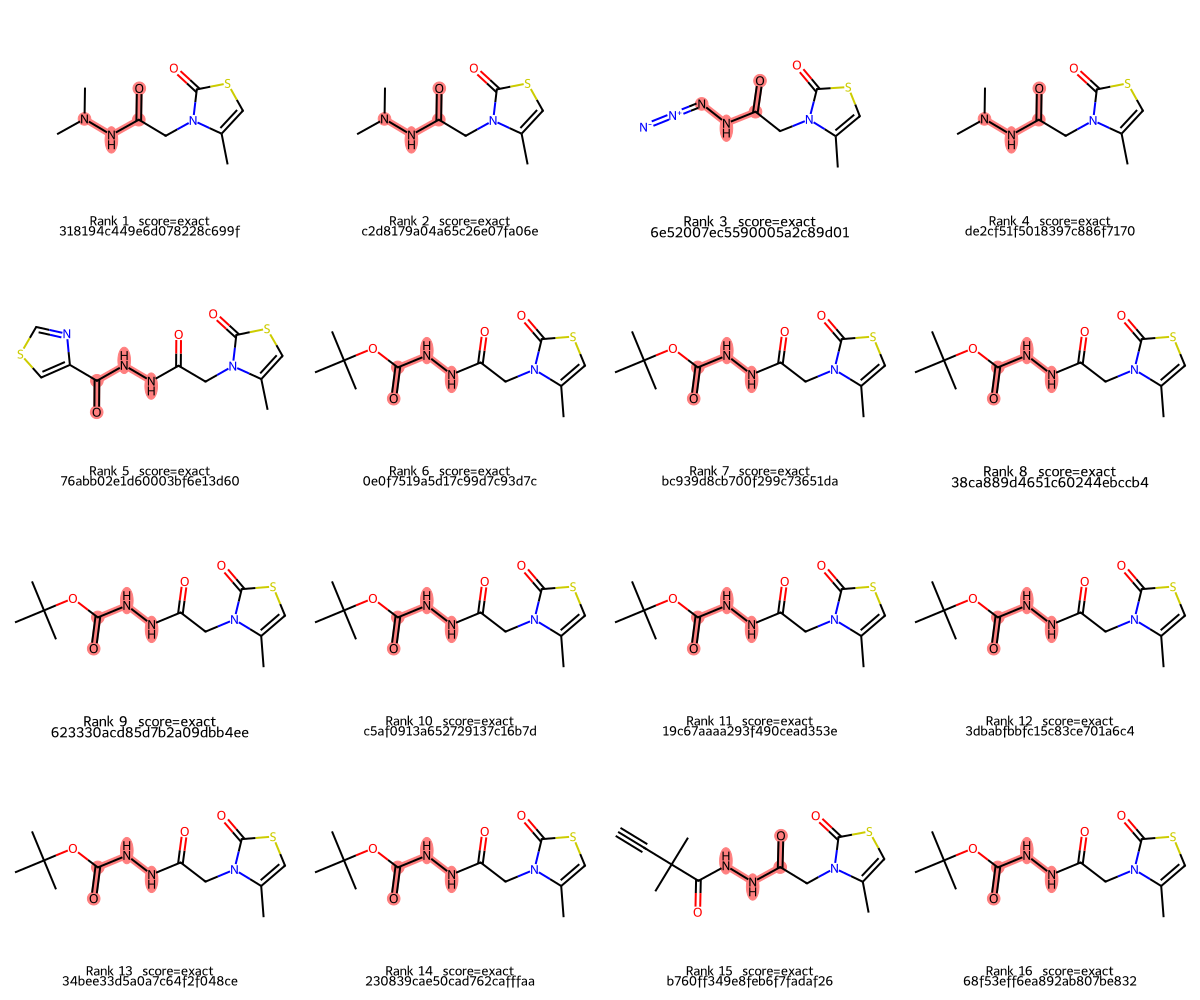

In [22]:
draw_highlighted("acyclic hydrazide")

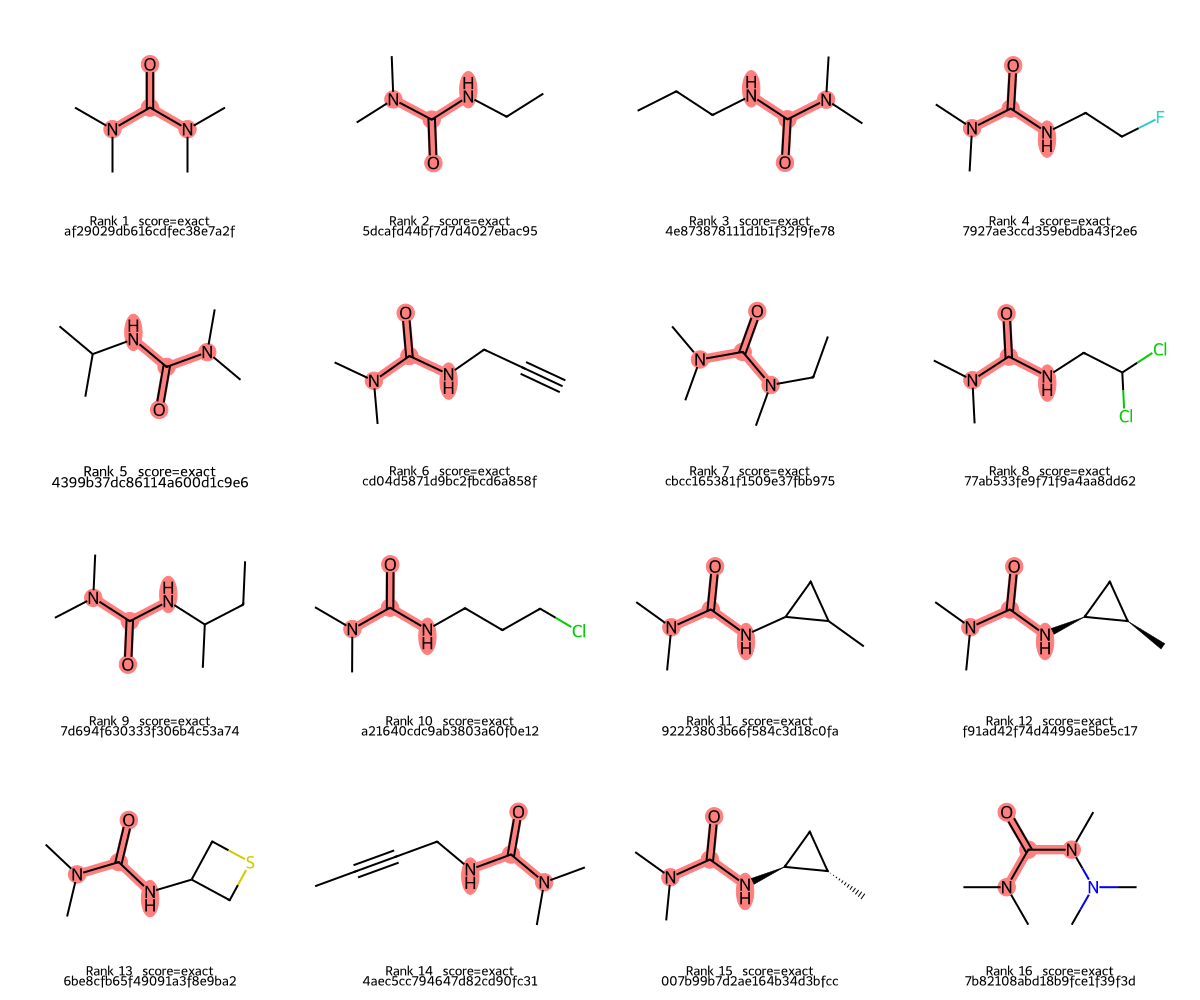

In [23]:
draw_highlighted("acyclic urea")

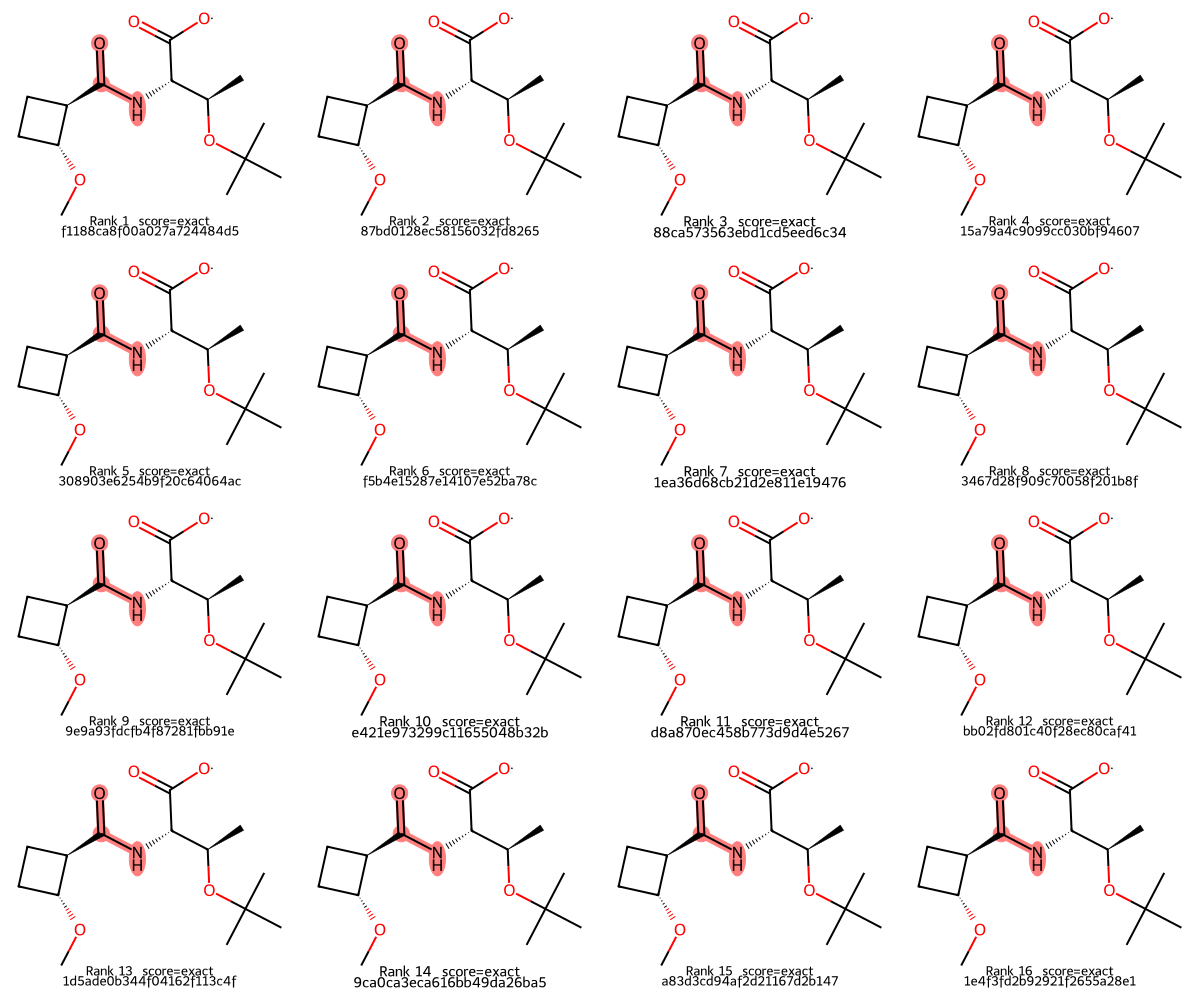

In [24]:
draw_highlighted("protic amide or acid")